In [1]:
import pandas as pd
import tensorflow as tf
from pathlib import Path

PROJECT_DIR = Path("..")
SPLITS_DIR = PROJECT_DIR / "data" / "splits"

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

print("Treino:", train_df.shape)
print("Teste:", test_df.shape)
print("TensorFlow:", tf.__version__)

I0000 00:00:1779324043.786315   23817 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779324043.900761   23817 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779324046.794729   23817 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Treino: (2197, 3)
Teste: (1465, 3)
TensorFlow: 2.21.0


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 5
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.one_hot(label, NUM_CLASSES)

    return image, label

In [4]:
train_paths = train_df["image_path"].values
train_labels = train_df["diagnosis"].values

test_paths = test_df["image_path"].values
test_labels = test_df["diagnosis"].values

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

E0000 00:00:1779324049.226700   23817 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
for images, labels in train_ds.take(1):
    print("Formato das imagens:", images.shape)
    print("Formato dos rótulos:", labels.shape)

W0000 00:00:1779324049.572000   24170 cpu_allocator_impl.cc:82] Allocation of 36636672 exceeds 10% of free system memory.
W0000 00:00:1779324054.267862   24167 cpu_allocator_impl.cc:82] Allocation of 36636672 exceeds 10% of free system memory.
W0000 00:00:1779324054.483760   24168 cpu_allocator_impl.cc:82] Allocation of 36636672 exceeds 10% of free system memory.
W0000 00:00:1779324057.823352   24167 cpu_allocator_impl.cc:82] Allocation of 36636672 exceeds 10% of free system memory.
I0000 00:00:1779324059.403959   24174 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 263 of 1000
W0000 00:00:1779324063.289689   24169 cpu_allocator_impl.cc:82] Allocation of 36636672 exceeds 10% of free system memory.
I0000 00:00:1779324069.520396   24174 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 505 of 1000
I0000 00:00:1779324088.462156   24174 shuffle_dataset_op.cc:483] Shuffle buffer filled.


Formato das imagens: (16, 224, 224, 3)
Formato dos rótulos: (16, 5)


I0000 00:00:1779324099.761055   24190 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 247 of 1000
I0000 00:00:1779324109.772340   24190 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 485 of 1000
I0000 00:00:1779324129.600724   24190 shuffle_dataset_op.cc:483] Shuffle buffer filled.


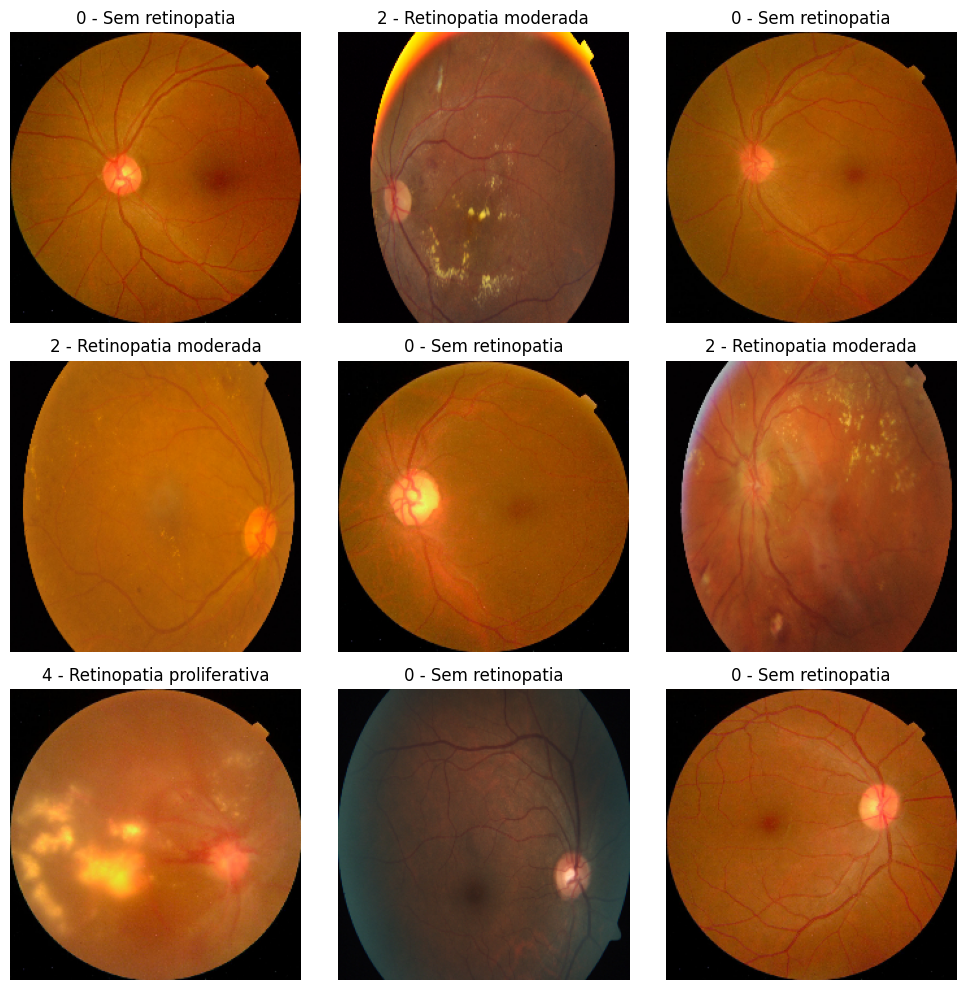

In [6]:
import matplotlib.pyplot as plt
import numpy as np

class_names = {
    0: "Sem retinopatia",
    1: "Retinopatia leve",
    2: "Retinopatia moderada",
    3: "Retinopatia severa",
    4: "Retinopatia proliferativa"
}

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())

        label_index = np.argmax(labels[i].numpy())
        plt.title(f"{label_index} - {class_names[label_index]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Aumento de Dados

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomZoom(0.05, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomTranslation(0.03, 0.03, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomFlip("horizontal"),
], name="data_augmentation")

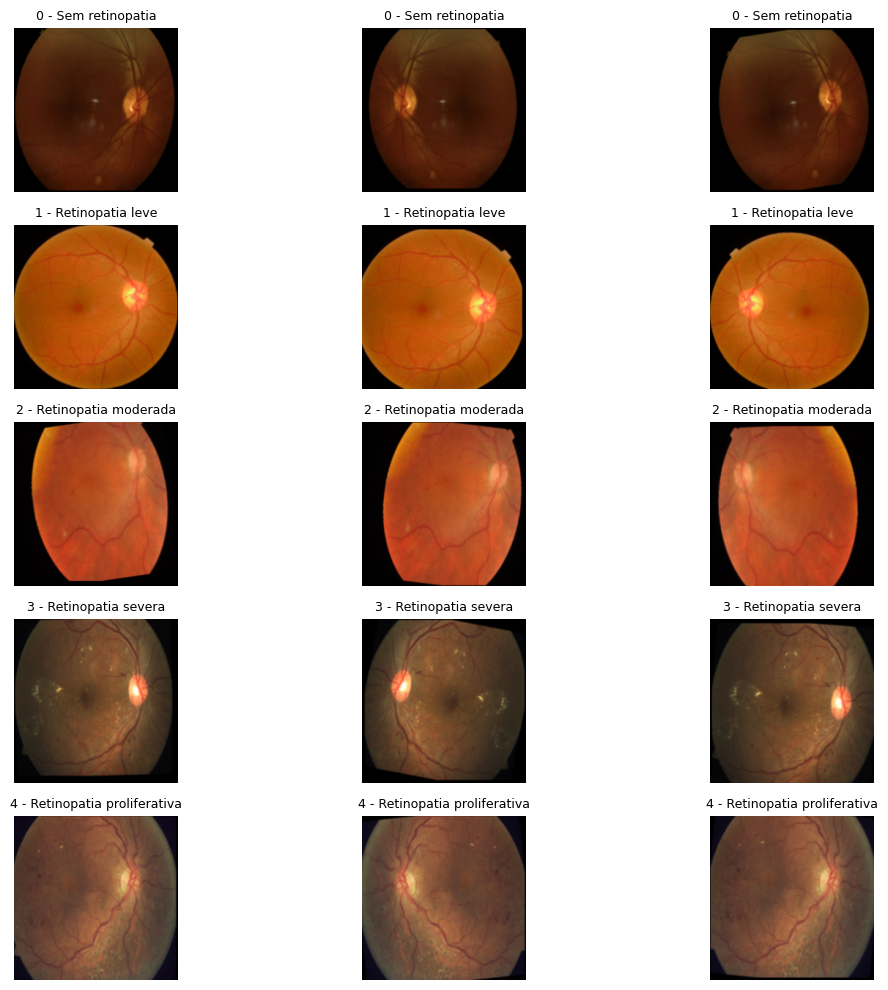

Figura salva em: ../results/figures/data_augmentation_examples_classes.png


In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

FIGURES_DIR = PROJECT_DIR / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 10))

plot_index = 1

for class_id in range(NUM_CLASSES):
    sample_row = train_df[train_df["diagnosis"] == class_id].sample(
        1,
        random_state=42
    ).iloc[0]

    image_path = sample_row["image_path"]
    label = sample_row["diagnosis"]

    image, label_one_hot = load_image(image_path, label)

    for j in range(3):
        augmented_image = data_augmentation(
            tf.expand_dims(image, axis=0),
            training=True
        )

        plt.subplot(NUM_CLASSES, 3, plot_index)
        plt.imshow(augmented_image[0].numpy())

        plt.title(f"{label} - {class_names[label]}", fontsize=9)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "data_augmentation_examples_classes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva em:", FIGURES_DIR / "data_augmentation_examples_classes.png")

In [9]:
def apply_augmentation(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels


train_ds_augmented = train_ds.map(
    apply_augmentation,
    num_parallel_calls=AUTOTUNE
)

In [10]:
for images, labels in train_ds_augmented.take(1):
    print("Formato das imagens aumentadas:", images.shape)
    print("Formato dos rótulos:", labels.shape)

I0000 00:00:1779324224.296574   24308 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 255 of 1000
I0000 00:00:1779324234.361003   24308 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 496 of 1000
I0000 00:00:1779324254.595986   24308 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 948 of 1000
I0000 00:00:1779324256.610088   24308 shuffle_dataset_op.cc:483] Shuffle buffer filled.


Formato das imagens aumentadas: (16, 224, 224, 3)
Formato dos rótulos: (16, 5)
